In [1]:
import numpy as np
import matplotlib.pyplot as plt

# WSN Simulation Parameters
NUM_NODES = 500  # Number of Sensor Nodes (SNs) deployed
AREA_SQM = 600   # Network size in sq.m [cite: 493]
BS_LOCATION = (0, 0) # Static Base Station (BS) coordinates

# Randomly deploy sensor nodes within the defined network area
# Scaling to roughly match the dimensions of a 600 sq.m area (~24.5m x 24.5m)
grid_size = np.sqrt(AREA_SQM) 
sensor_nodes = np.random.rand(NUM_NODES, 2) * grid_size

print(f"Deployed {NUM_NODES} sensor nodes in a {grid_size:.2f}m x {grid_size:.2f}m area.")

Deployed 500 sensor nodes in a 24.49m x 24.49m area.


In [2]:
from sklearn.cluster import MeanShift

# The paper identifies 0.15 as the optimal bandwidth for the KDE[cite: 477].
# In a real-world physical grid, this value is often scaled to the transmission proximity (rc).
# For this script, we will use a raw bandwidth of 3.0 meters for visual clarity in the plot.
OPTIMAL_BANDWIDTH = 3.0 

# Initialize the Mean-Shift algorithm
# Note: The default flat kernel behaves exactly like the paper's Tophat kernel
mscvp_algorithm = MeanShift(bandwidth=OPTIMAL_BANDWIDTH, bin_seeding=True)

# Execute the algorithm to find the Visiting Points (VPs)
mscvp_algorithm.fit(sensor_nodes)

# Extract the calculated Visiting Points and the node assignments
visiting_points = mscvp_algorithm.cluster_centers_
node_assignments = mscvp_algorithm.labels_

num_vps = len(visiting_points)
print(f"MSCVP Algorithm identified {num_vps} optimal Visiting Points (VPs) for the mobile sink.")

MSCVP Algorithm identified 23 optimal Visiting Points (VPs) for the mobile sink.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_16000\461546674.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_vps)


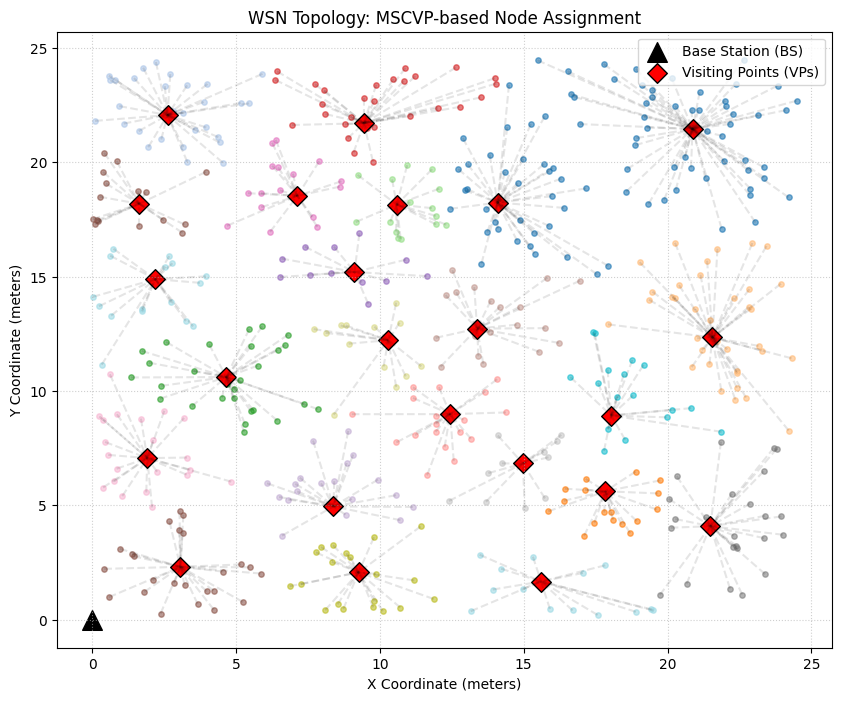

In [3]:
plt.figure(figsize=(10, 8))

# Plot the Base Station
plt.scatter(BS_LOCATION[0], BS_LOCATION[1], c='black', marker='^', s=200, label='Base Station (BS)')

# Colors for different clusters to show single-hop assignments
colors = plt.cm.get_cmap('tab20', num_vps)

# Plot Sensor Nodes and their connection to their designated VP
for i in range(num_vps):
    # Filter nodes assigned to the current VP
    cluster_nodes = sensor_nodes[node_assignments == i]
    vp_coord = visiting_points[i]
    
    # Plot the sensor nodes
    plt.scatter(cluster_nodes[:, 0], cluster_nodes[:, 1], s=15, color=colors(i), alpha=0.6)
    
    # Draw dashed lines representing the single-hop transmission path
    for node in cluster_nodes:
        plt.plot([node[0], vp_coord[0]], [node[1], vp_coord[1]], 'k--', alpha=0.1)

# Plot the Visiting Points (VPs)
plt.scatter(visiting_points[:, 0], visiting_points[:, 1], c='red', marker='D', s=100, 
            edgecolor='black', label='Visiting Points (VPs)')

plt.title("WSN Topology: MSCVP-based Node Assignment")
plt.xlabel("X Coordinate (meters)")
plt.ylabel("Y Coordinate (meters)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()